In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

In [2]:
df = pd.read_csv("./datalog_trial_0.csv", header=None)

In [3]:
df.head()

,0,1,2,3,4
0,2024-10-19 22:10:57,0.0000,563,1.8,3.0
1,2024-10-19 22:11:31,0.0000,562,1.9,2.6
2,2024-10-19 22:13:37,17.7888,560,2.0,2.9
3,2024-10-19 22:18:37,17.7888,569,1.9,3.3
4,2024-10-19 22:23:37,17.7888,596,2.0,3.8


In [4]:
df.dtypes

0     object
1    float64
2      int64
3    float64
4    float64
dtype: object

In [5]:
df[0] = pd.to_datetime(df[0])

In [6]:
df.dtypes

0    datetime64[ns]
1           float64
2             int64
3           float64
4           float64
dtype: object

<Axes: >

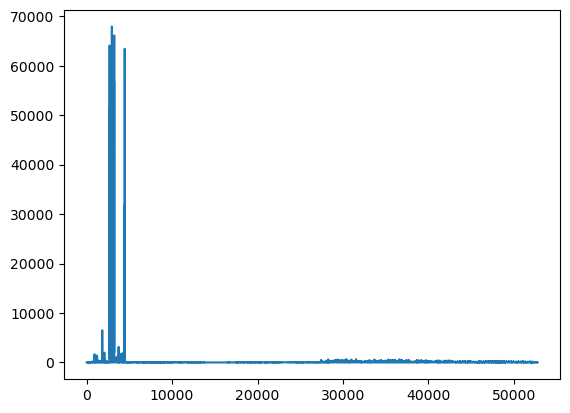

In [7]:
df[1].plot()

<Axes: >

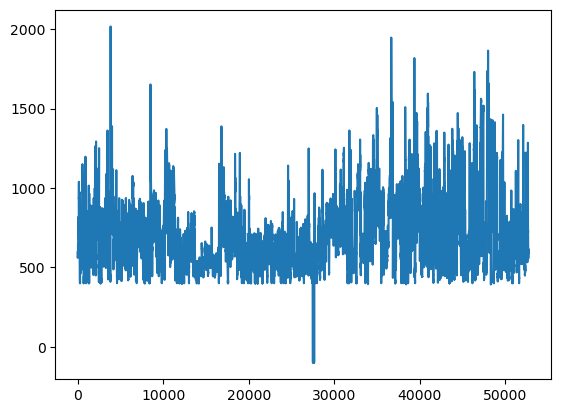

In [8]:
df[2].plot()

<Axes: >

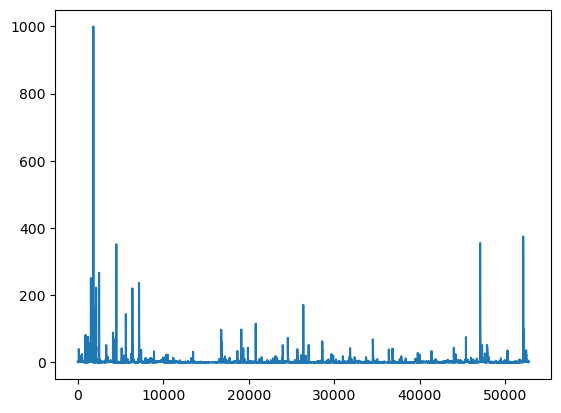

In [9]:
df[3].plot()

<Axes: >

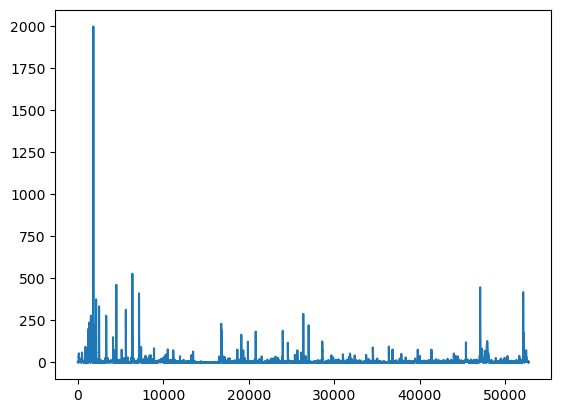

In [10]:
df[4].plot()

In [11]:
df.columns

Index([0, 1, 2, 3, 4], dtype='int64')

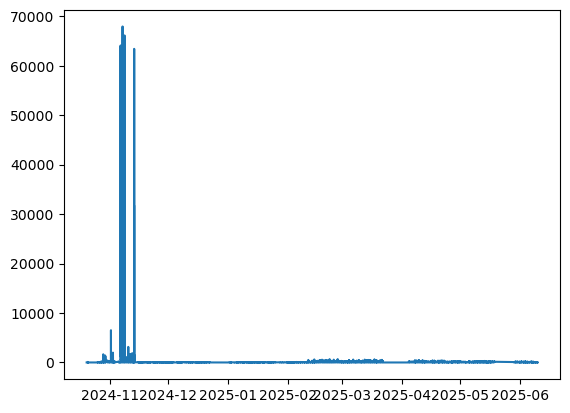

In [12]:
fig, ax = plt.subplots(1, 1)
ax.plot(df[0], df[1])

In [13]:
# remove outliers
cleaned_df = df[(np.abs(stats.zscore(df[[1,2,3,4]])) < 3).all(axis=1)]

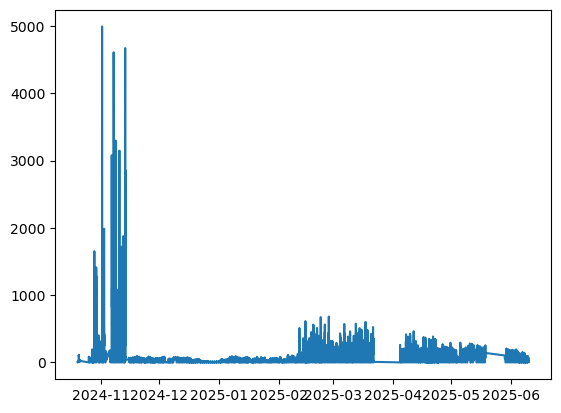

In [14]:
fig, ax = plt.subplots(1, 1)
ax.plot(cleaned_df[0], cleaned_df[1])

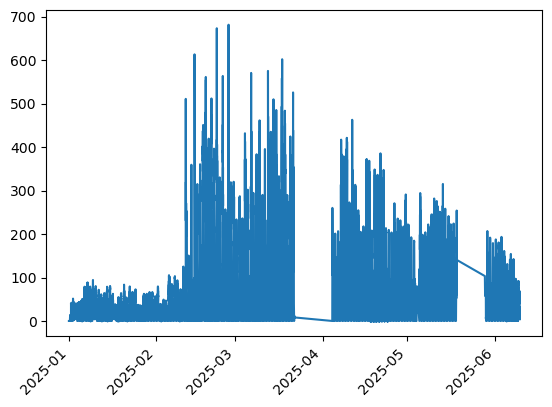

In [15]:
df_2025 = df[df[0].dt.year == 2025].copy()

fig, ax = plt.subplots(1, 1)
ax.plot(df_2025[0], df_2025[1])
fig.autofmt_xdate(rotation=45)

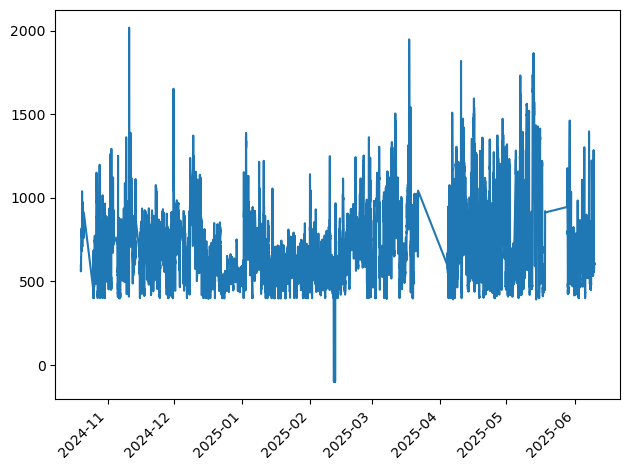

In [52]:
fig, ax = plt.subplots(1, 1, layout='tight')
ax.plot(df[0], df[2])
fig.autofmt_xdate(rotation=45)


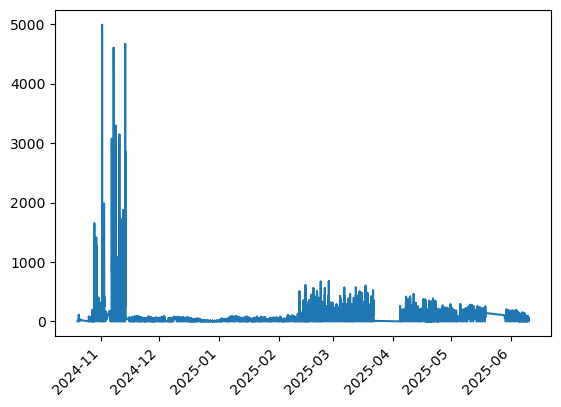

In [17]:
fig, ax = plt.subplots(1, 1)
ax.plot(cleaned_df[0], cleaned_df[1])
fig.autofmt_xdate(rotation=45)

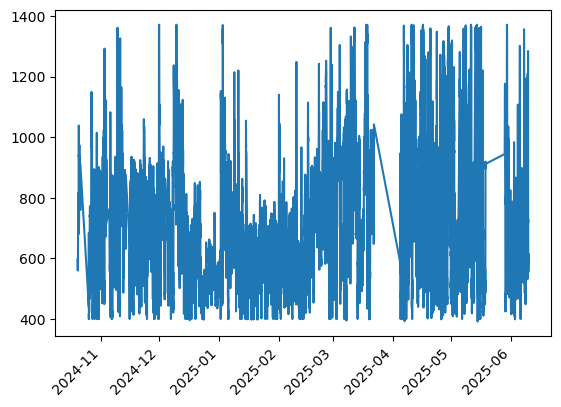

In [18]:
fig, ax = plt.subplots(1, 1)
ax.plot(cleaned_df[0], cleaned_df[2])
fig.autofmt_xdate(rotation=45)

In [19]:
mean_aq = df.groupby(pd.Grouper(key=0,freq='1D')).mean().reset_index()

In [20]:
mean_aq

,0,1,2,3,4
0,2024-10-19,5.453600,574.666667,1.845833,3.041667
1,2024-10-20,28.254191,813.233645,8.838785,12.905607
2,2024-10-21,22.603500,819.000000,1.975000,4.650000
3,2024-10-22,NaN,NaN,NaN,NaN
4,2024-10-23,NaN,NaN,NaN,NaN
...,...,...,...,...,...
229,2025-06-05,40.405970,676.391791,1.272388,3.520149
230,2025-06-06,54.385204,662.323420,1.366171,3.009665
231,2025-06-07,41.126543,639.866171,15.627881,20.644610
232,2025-06-08,31.840781,699.312268,7.565056,12.762082


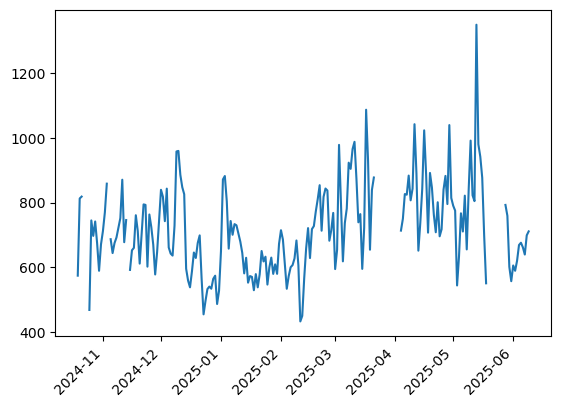

In [54]:
fig, ax = plt.subplots(1, 1)
ax.plot(mean_aq[0], mean_aq[2])
fig.autofmt_xdate(rotation=45)

In [22]:
mean_aq_2025 = df_2025.groupby(pd.Grouper(key=0,freq='1D')).mean().reset_index()

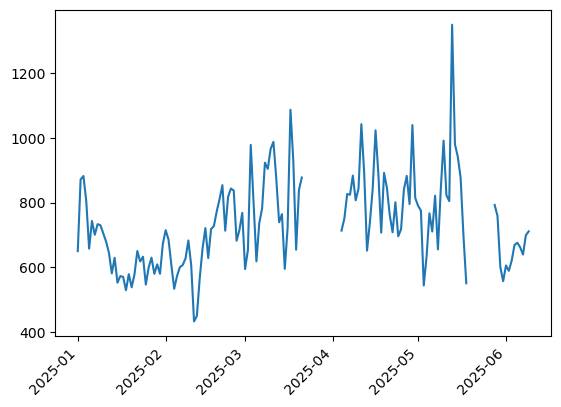

In [50]:
fig, ax = plt.subplots(1, 1)
ax.plot(mean_aq_2025[0], mean_aq_2025[2])
fig.autofmt_xdate(rotation=45)

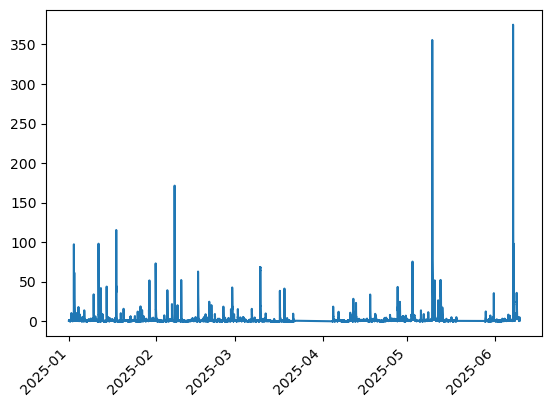

In [48]:
fig, ax = plt.subplots(1, 1)
ax.plot(df_2025[0], df_2025[3])
fig.autofmt_xdate(rotation=45)

In [25]:
monthly_mean = cleaned_df.groupby(pd.Grouper(key=0,freq='1ME')).mean().reset_index()

In [26]:
monthly_mean

,0,1,2,3,4
0,2024-10-31,60.059555,692.028245,4.042368,6.582933
1,2024-11-30,81.764313,700.051216,1.884590,3.854377
2,2024-12-31,15.773815,653.576062,1.166976,2.549653
3,2025-01-31,21.216618,646.313999,1.451380,3.039441
4,2025-02-28,58.254413,683.419006,1.358275,2.795032
5,2025-03-31,80.802625,798.225718,1.100873,2.522154
6,2025-04-30,70.271158,813.259518,1.382604,3.136261
7,2025-05-31,61.243280,726.018447,1.559051,3.449564
8,2025-06-30,47.749843,646.745331,2.043251,4.037309


<Axes: >

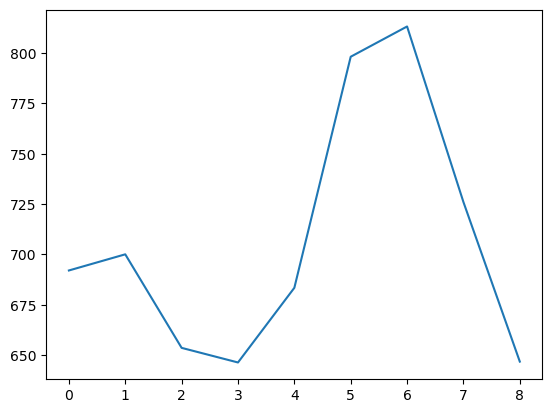

In [55]:
monthly_mean[2].plot()

<Axes: >

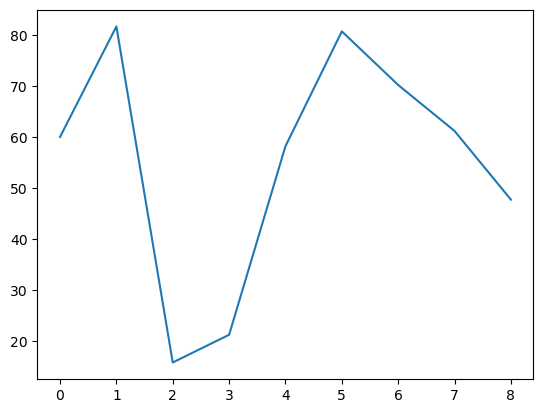

In [28]:
monthly_mean[1].plot()

<Axes: >

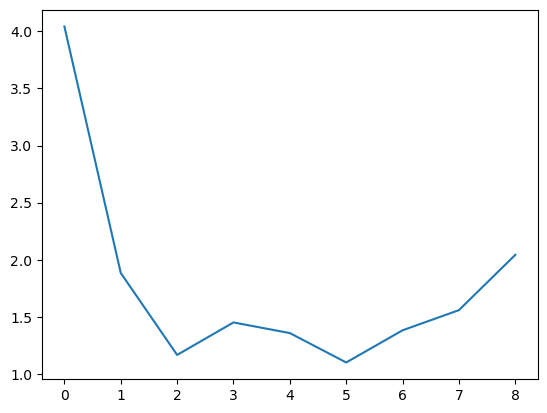

In [29]:
monthly_mean[3].plot()

In [30]:
weekly_mean = cleaned_df.groupby(pd.Grouper(key=0, freq="1W")).mean().reset_index()

In [31]:
weekly_mean

,0,1,2,3,4
0,2024-10-20,25.008490,787.493617,7.735319,11.377872
1,2024-10-27,14.605532,673.161017,3.783220,6.752373
2,2024-11-03,104.723110,720.912338,2.846039,4.737013
3,2024-11-10,201.201580,693.039858,1.830320,3.923203
4,2024-11-17,80.153491,706.669505,1.549381,3.133514
5,2024-11-24,24.948187,699.028070,1.877251,3.739649
6,2024-12-01,22.781155,694.611143,2.033429,4.480241
7,2024-12-08,22.497706,706.924476,1.981888,3.740140
8,2024-12-15,30.604503,794.950903,1.476806,3.719470
9,2024-12-22,13.025546,620.080362,1.082437,2.517722


<Axes: >

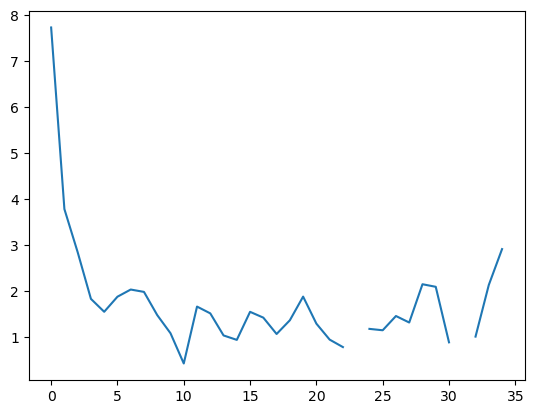

In [59]:
weekly_mean[3].plot()

In [33]:
cleaned_df.loc[(cleaned_df[0] < "2024-11-01") & (cleaned_df[3] > 4)]

,0,1,2,3,4
111,2024-10-20 09:23:24,28.8864,772,6.2,13.8
112,2024-10-20 09:28:24,28.8864,741,7.2,15.0
113,2024-10-20 09:33:24,34.4352,745,8.0,15.9
114,2024-10-20 09:38:24,37.0464,693,7.4,16.2
115,2024-10-20 09:43:25,32.9664,681,7.2,13.6
...,...,...,...,...,...
1610,2024-10-31 17:41:40,59.2400,638,4.2,11.3
1611,2024-10-31 17:46:42,53.6900,605,5.1,13.1
1615,2024-10-31 18:06:46,38.5200,537,4.3,8.7
1616,2024-10-31 18:11:47,37.0500,550,4.3,10.2


<Axes: xlabel='0'>

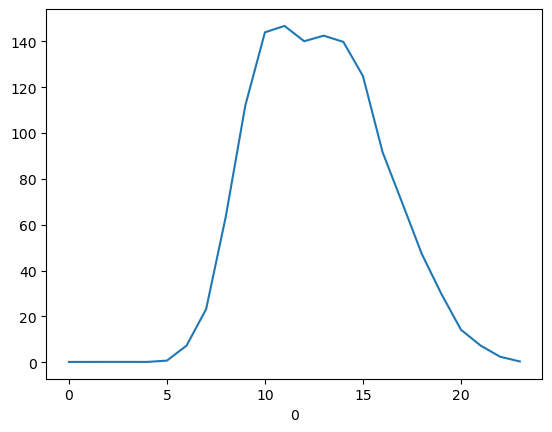

In [63]:
df_2025.groupby(df_2025[0].dt.hour)[1].mean().plot()

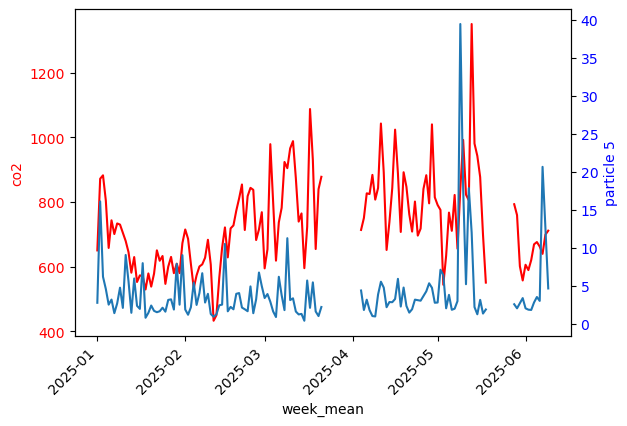

In [35]:
fig, ax = plt.subplots()
ax.plot(mean_aq_2025[0], mean_aq_2025[2], color='red')
ax.set_xlabel('week_mean')
ax.set_ylabel('co2', color='red')
ax.tick_params(axis='y', labelcolor='red')

ax2 = ax.twinx()
ax2.plot(mean_aq_2025[0], mean_aq_2025[4])
ax2.set_ylabel('particle 5', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

fig.autofmt_xdate(rotation=45)

In [36]:
cleaned_min_weekly = cleaned_df.groupby(pd.Grouper(key=0, freq='1W')).min()
cleaned_max_weekly = cleaned_df.groupby(pd.Grouper(key=0, freq='1W')).max()

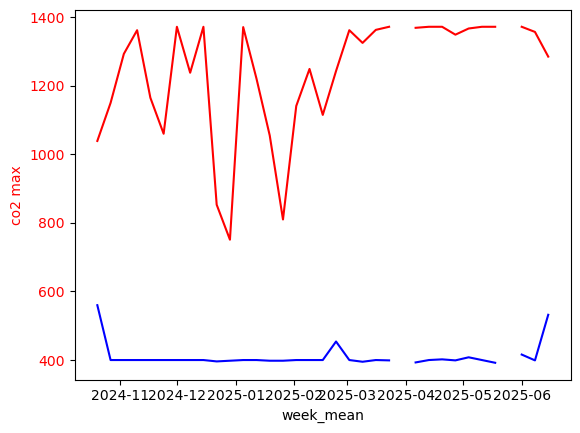

In [37]:
fig, ax1 = plt.subplots()
ax1.plot(cleaned_min_weekly.index, cleaned_min_weekly[2], color='blue')
ax1.set_xlabel('week_mean')
ax1.set_ylabel('co2 min', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')



ax1.plot(cleaned_max_weekly.index, cleaned_max_weekly[2], color='red')
ax1.set_xlabel('week_mean')
ax1.set_ylabel('co2 max', color='red')
ax1.tick_params(axis='y', labelcolor='red')

array([[<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
       [<Axes: title={'center': '2'}>, <Axes: title={'center': '3'}>],
       [<Axes: title={'center': '4'}>, <Axes: >]], dtype=object)

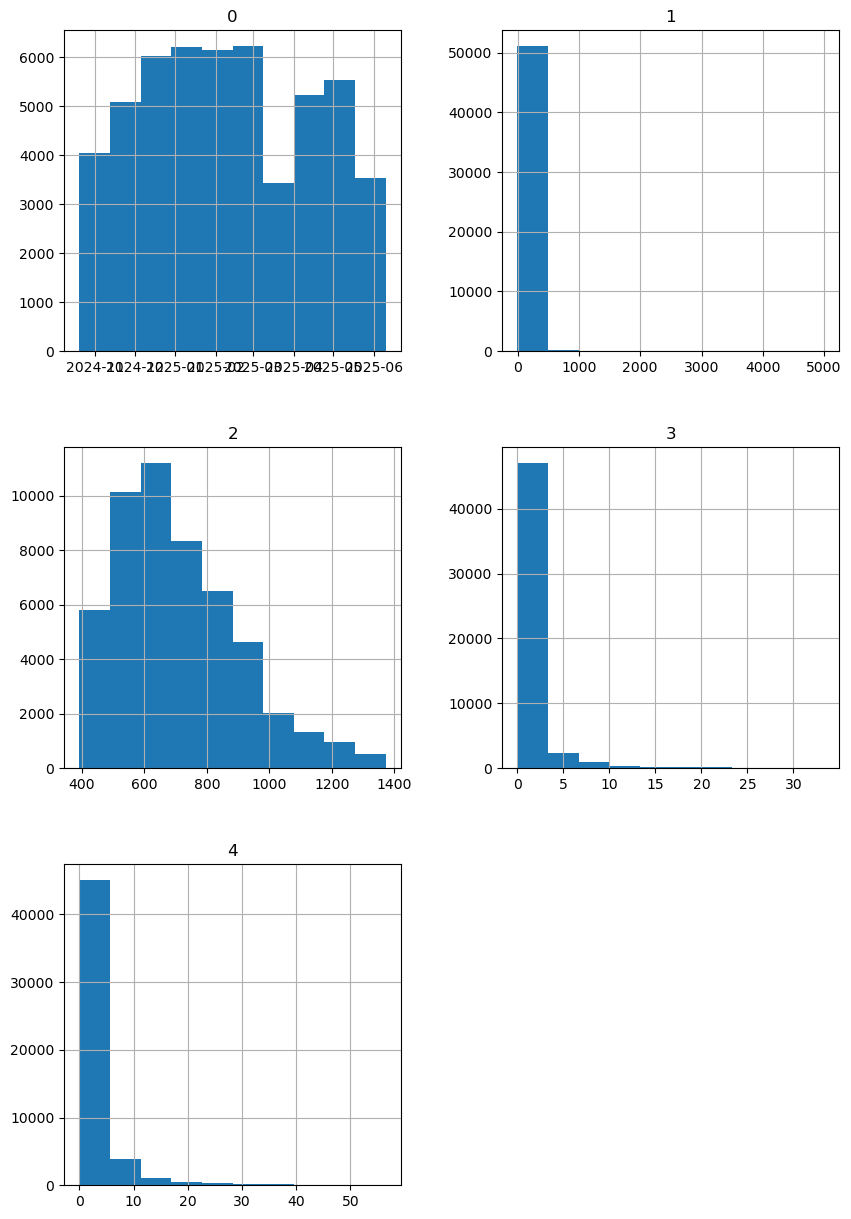

In [38]:
cleaned_df.hist(figsize=(10, 15))

<Axes: >

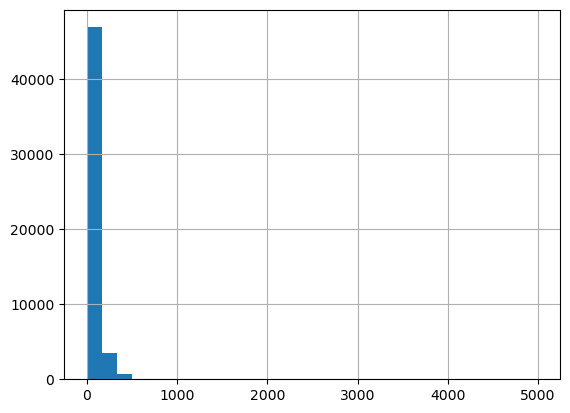

In [39]:
cleaned_df[1].hist(bins=30)

In [40]:
cleaned_df[3].max()

33.3

In [41]:
cleaned_df.loc[cleaned_df[3] == cleaned_df[3].max()]

,0,1,2,3,4
129,2024-10-20 10:53:26,98.736,1028,33.3,47.2
52138,2025-06-07 13:40:27,91.230,784,33.3,37.4


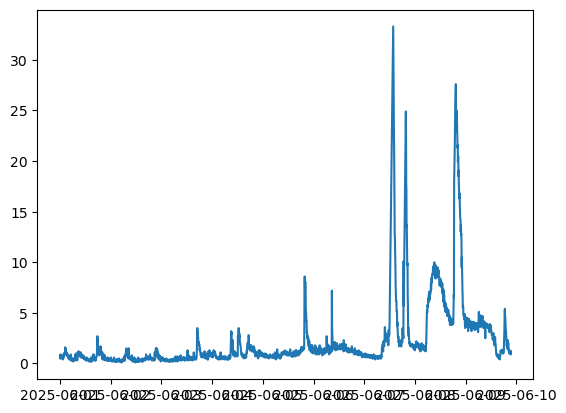

In [65]:
june = cleaned_df[cleaned_df[0] > "2025-06-01"].copy()

fig, ax = plt.subplots(1, 1)
ax.plot(june[0], june[3])

In [43]:
import datetime

In [44]:
cleaned_df.loc[cleaned_df[0] >= pd.to_datetime(datetime.datetime.today().date()), 2].mean()

np.float64(711.5083333333333)

In [45]:
monthly_mean[2].values[-1]

np.float64(646.7453310696095)